In [2]:
import random as rand
import matplotlib.pyplot as plt
import itertools
import pandas as pd
# from pyBKT.models import Model
import os
import joblib
from tqdm import tqdm
import json
from Models.ELO import Elo

In [3]:
import numpy as np

def probability(theta, b):
    p = 1 / (1 + np.exp(-(theta - b)))
    return p

In [14]:
# Load the configuration from the JSON file and us the variables
with open('elo_variable.json', 'r') as Elo_Data:
    elo_data = json.load(Elo_Data)

print(elo_data)

{'globals': {'students': 500, 'init_skill_level': [0.0, 0.0], 'k_success': 1, 'k_fail': 0.5}, 'scenarios': [{'id': 1, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 0], [0, 1]], 'difficulty_level': [1, 1], 'depends': [-1, -1]}, {'id': 2, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 1], [1, 1]], 'difficulty_level': [0, 1], 'depends': [-1, -1]}, {'id': 3, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0], [0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1], 'depends': [-1, -1, -1, -1]}, {'id': 4, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1], [0, 1, 1, 1]], 'difficulty_level': [1, 1, 0, 1], 'depends': [-1, -1, -1, -1]}, {'id': 5, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1, 0, 1], [0, 1, 1, 0, 1, 1]], 'difficulty_level': [0, 0, 0, 1, 1, 1], 'depends': [-1, -1, -1, -1, -1, -1]}, {'id': 6, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0, 1, 0], [0, 1, 0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1, 2, 2], 'depends': [-1, -1, -1, -1, -1, -1]}

for student in students:
    while not all skill is mastered:
        choose task randomly (maybe we can only choose if it trains this skill?)
        update skill in elo
        inc step
        put in dataframe

In [15]:
def split_and_save_data(df, scenario_id):
    unique_students = df['student_id'].unique()

    # Calculate the number of students for training and testing
    num_train_students = 400 
    num_test_students  =  50 
    num_val_students   = 50

    # Split student IDs into train and test sets
    train_student_ids = unique_students[:num_train_students]
    test_student_ids = unique_students[num_train_students:num_train_students + num_test_students]
    vali_student_ids = unique_students[num_train_students+num_test_students:num_train_students + num_test_students+num_val_students]

    # Filter the data for train, test and vali sets based on student IDs
    train_data = df[df['student_id'].isin(train_student_ids)]
    test_data  = df[df['student_id'].isin(test_student_ids)]
    vali_data  = df[df['student_id'].isin(vali_student_ids)]
    y_test     = test_data['success']

    HOMEDIR = os.getcwd()
    folder_path = HOMEDIR + "/Simulated_Data/"

    train_data.to_csv(os.path.join(folder_path, f'scenario_{scenario_id}_train_data.csv'), index=False)
    test_data.to_csv(os.path.join(folder_path,  f'scenario_{scenario_id}_test_data.csv'),  index=False)
    vali_data.to_csv(os.path.join(folder_path,  f'scenario_{scenario_id}_vali_data.csv'),  index=False)

In [16]:
def generate_simulated_data_per_condition(scenario_data):

    scenario_id    = scenario_data["id"]
    num_tasks      = scenario_data["num_tasks"]
    num_skills     = scenario_data["num_skills"]
    q_matrix       = np.array(scenario_data["q_matrix"])
    difficulty_level = np.array(scenario_data["difficulty_level"])
    depends        = scenario_data["depends"]

    records = []
    level_skill_first_student = []

    for student_id in tqdm(range(students), desc=f"Scenario {scenario_id}", leave=False):
        skill_level = np.copy(init_skill_level)
        step = 0

        while np.any(skill_level <= mastery_level):
            task = np.random.randint(0, num_tasks)

            skill_level, success = Elo.skill_update(
                    difficulty_level[task],
                    skill_level,
                    q_matrix[:, task],
                    depends,
                    k_success,
                    k_fail
            )

            step += 1

            if student_id == 0:
                level_skill_first_student.append(skill_level.tolist())

            for skill_id in range(q_matrix.shape[0]):
                    if q_matrix[skill_id, task] == 1:
                        records.append({
                            "student_id":   student_id,
                            "task":         task,
                            "skill_id":     skill_id,
                            "success":      success,
                            "step":         step
                        })

    df = pd.DataFrame(records, columns=["student_id", "task", "skill_id", "success", "step"])

    split_and_save_data(df, scenario_id)
        
    return df, level_skill_first_student

In [17]:
all_data = {}

level_skill   = [] 
mastery_level = 1.5
i = 0

global_values = elo_data["globals"]
scenarios = elo_data["scenarios"]

students          = global_values["students"]
init_skill_level  = np.array(global_values["init_skill_level"])
k_success         = global_values["k_success"]
k_fail            = global_values["k_fail"]

for scenario in scenarios:
    scenario_id    = scenario["id"]
    scenario_df, skill_progress = generate_simulated_data_per_condition(scenario)
    all_data[scenario_id] = {
        "df":               scenario_df,
        "skill_progression": skill_progress
    }

In [20]:
def plot_student_progress(Level_Skill, scenario_id):
    x_values = list(range(1, len(Level_Skill) + 1))
    
    paired_lists = [[Level_Skill[j][i] for j in range(len(Level_Skill))] for i in range(len(Level_Skill[0]))]
    num_lines = len(paired_lists)
    colors = plt.cm.viridis(np.linspace(0, 1, num_lines))
    
    plt.figure(figsize=(8, 4))
    
    for i in range(num_lines):
        plt.plot(x_values, paired_lists[i], linestyle='-', color=colors[i], label=f'Skill {i+1}')
    
    # Label the axes
    plt.xlabel('Time')
    plt.ylabel('Skill Level')
    
    # Add a legend and grid 
    plt.title(f'Scenario {scenario_id}')
    plt.legend()
    plt.grid(True)

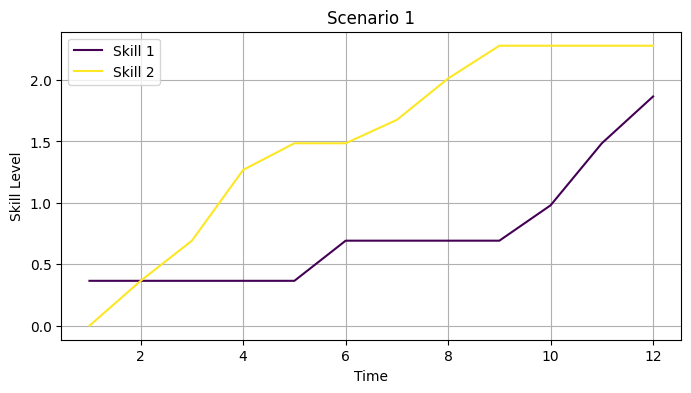

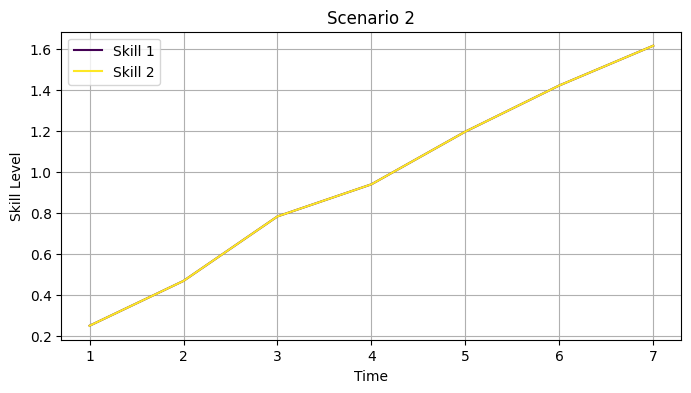

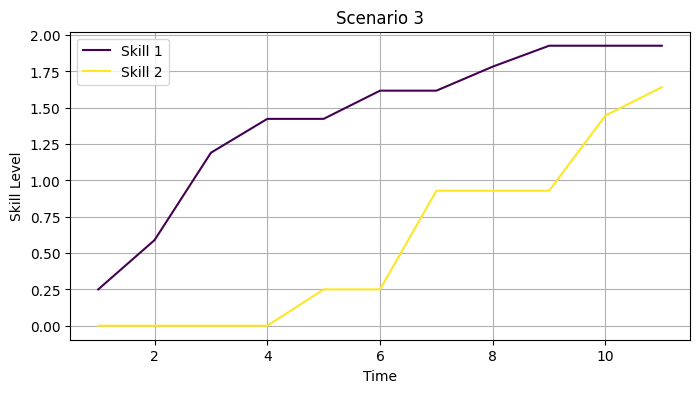

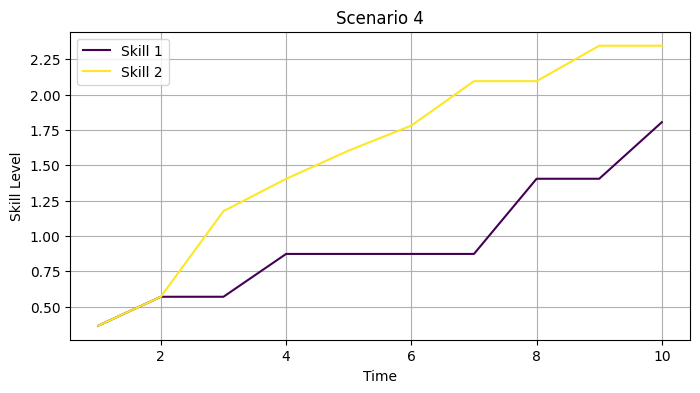

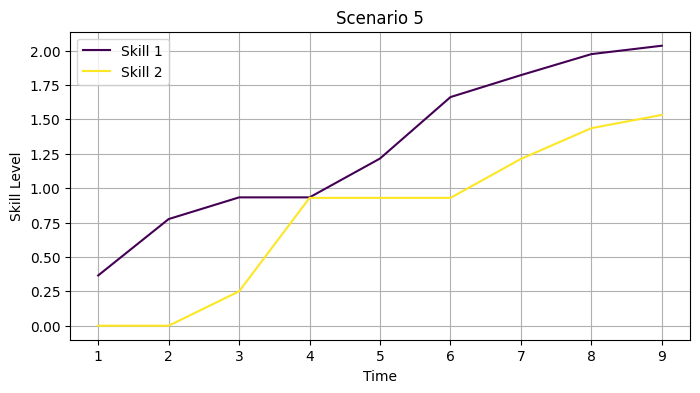

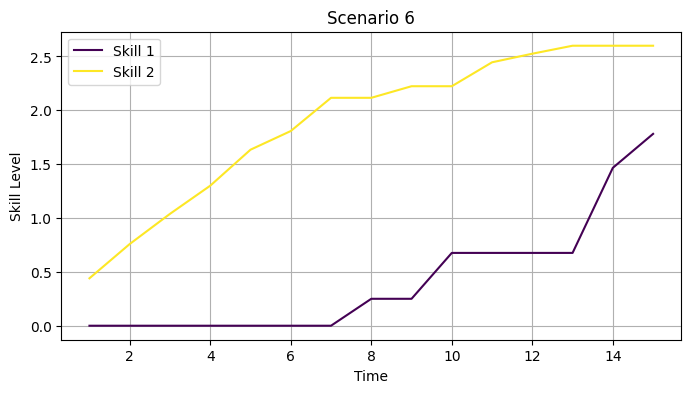

In [21]:
for scenario_id, data in all_data.items():
    plot_student_progress(data["skill_progression"], scenario_id)